In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hprinceprajapat1402","key":"8d9c29188838ced45c86b4671bde3fad"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d rohan0301/unsupervised-learning-on-country-data

Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data
License(s): MIT
100% 5.21k/5.21k [00:00<00:00, 11.1MB/s]



In [ ]:
!unzip unsupervised-learning-on-country-data.zip

Archive:  unsupervised-learning-on-country-data.zip
  inflating: Country-data.csv        
  inflating: data-dictionary.csv     


In [ ]:
!ls


Country-data.csv     kaggle.json  unsupervised-learning-on-country-data.zip
data-dictionary.csv  sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
# data  preprcessing firsgt ---

In [ ]:
X = df.drop("country", axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#cllustering data now ----

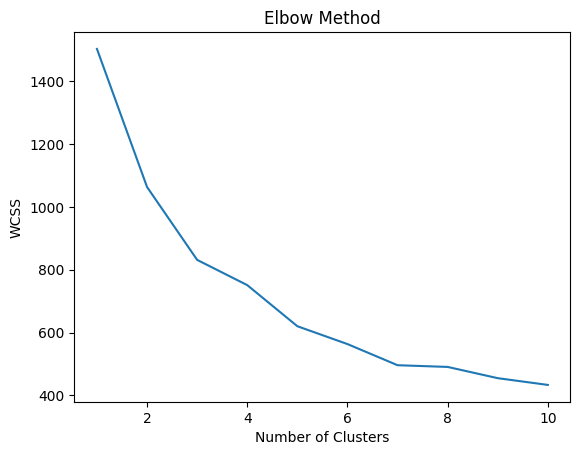

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state= 42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [ ]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


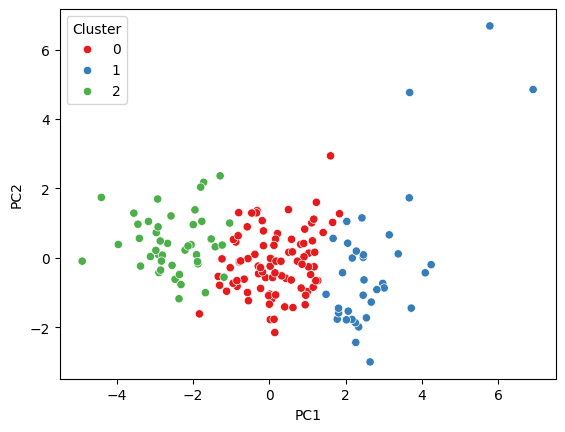

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df["PC1"] = principal_components[:,0]
df["PC2"] = principal_components[:,1]

import seaborn as sns

sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set1")
plt.show()

In [ ]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,PC1,PC2
Cluster,,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,0.148884,-0.133574
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,2.769773,-0.213014
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-2.500352,0.425686


In [ ]:
cluster_map = {
    0: "Developing",
    1: "Developed",
    2: "Underdeveloped"
}

df["Cluster_Label"] = df["Cluster"].map(cluster_map)

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_clusters
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


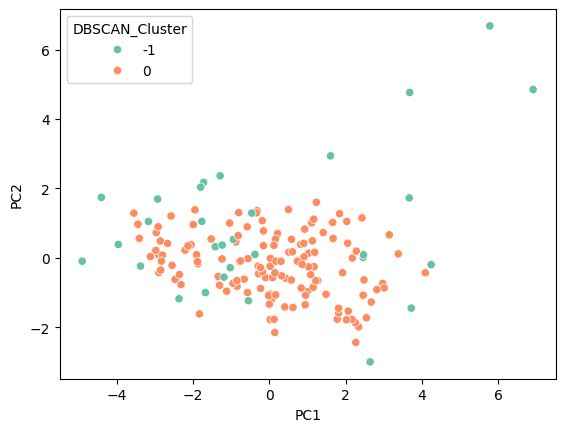

In [ ]:
sns.scatterplot(data=df, x="PC1", y="PC2", hue="DBSCAN_Cluster", palette="Set2")
plt.show()

In [ ]:
#classification now -----

In [ ]:
X = df.drop(["country", "Cluster", "Cluster_Label", "DBSCAN_Cluster", "PC1", "PC2"], axis=1)
y = df["Cluster_Label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         8
    Developing       1.00      1.00      1.00        20
Underdeveloped       1.00      1.00      1.00         6

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



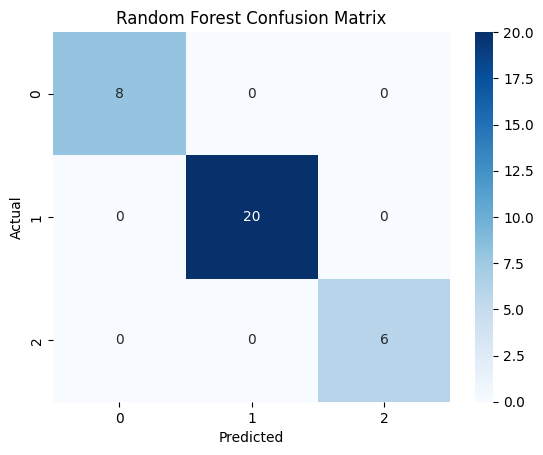

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

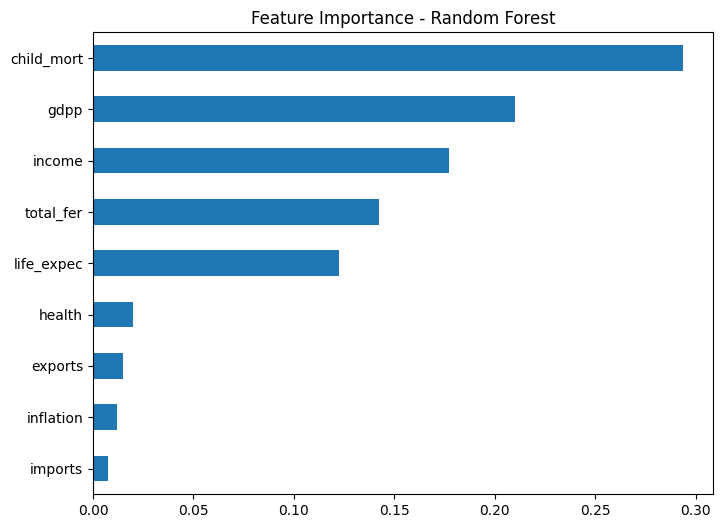

In [ ]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

xgb.fit(X_train, y_train_encoded)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
y_pred_decoded = le.inverse_transform(y_pred_xgb)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_decoded))
print("\nClassification Report:\n", classification_report(y_test, y_pred_decoded))

XGBoost Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         8
    Developing       1.00      1.00      1.00        20
Underdeveloped       1.00      1.00      1.00         6

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



1. Predictive Performance

Random Forest Accuracy: 100%,
XGBoost Accuracy: 100%,
Perfect precision, recall, and F1-score across all classes,  
Zero misclassifications in confusion matrix.

This indicates strong separability between development categories.


2. Key Feature Importance

Top drivers of country classification:

Child Mortality Rate,
GDP per capita,
Income Level,
Fertility Rate,
Life Expectancy,

Child mortality emerged as the most influential predictor of development status.


3. Actionable Insights
Countries with high child mortality and low GDP cluster as underdeveloped.
High GDP and income strongly correlate with developed status.
DBSCAN identified 30 outlier countries with extreme economic conditions.

These insights can support policy planning, investment decisions, and economic development strategies.


 **Conclusion**
The integrated clustering and ensemble learning framework successfully segmented countries into meaningful development categories and achieved optimal predictive performance, demonstrating the effectiveness of combining unsupervised and supervised learning approaches.
